In [83]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/AI DATASET/7. Racist Sexist or Not Dataset/train_racisit.csv")
test = pd.read_csv("/content/drive/MyDrive/AI DATASET/7. Racist Sexist or Not Dataset/test_racisit.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (31962, 3)
Test shape : (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


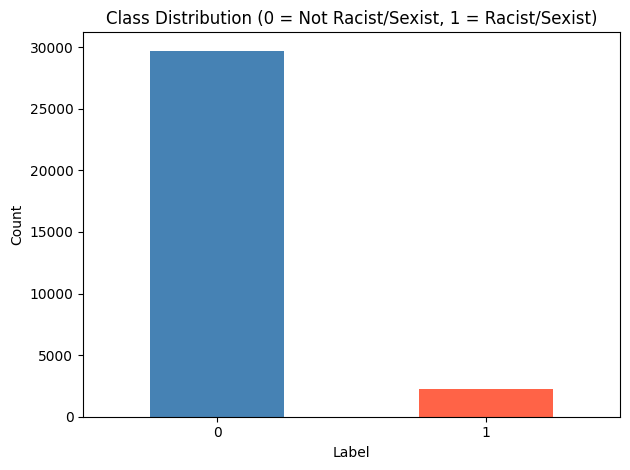

label
0    29720
1     2242
Name: count, dtype: int64


In [84]:
import matplotlib.pyplot as plt

train['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Class Distribution (0 = Not Racist/Sexist, 1 = Racist/Sexist)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train['label'].value_counts())

In [85]:
!pip install contractions

In [86]:
import re
import nltk
import contractions                          # handles contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand contractions (e.g. "don't" -> "do not")
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Step 4: Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Step 5: Remove hashtag symbols (keep the word)
    text = re.sub(r"#", "", text)

    # Step 6: Remove numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Step 7: Tokenise, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

train['clean_text'] = train['tweet'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [87]:
# Show before/after
train[['tweet', 'clean_text']].head(10)

,tweet,clean_text
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use offer wheelchair...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love take time
4,factsguide: society now #motivation,factsguide society motivation
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,the next school year is the year for exams.ð...,next school year year exam cannot think school...
8,we won!!! love the land!!! #allin #cavs #champ...,love land allin cavs champion cleveland clevel...
9,@user @user welcome here ! i'm it's so #gr...,welcome gr


In [88]:
train[['clean_text']].sample(10)

,clean_text
16226,ltlthe good man traitor like bo hoe clinton power
31202,gig one added ivan oiz lucas gig conce cafe love
4102,thank yogi team great week yoga yyc fundaysund...
24,tgif ff gamedev indiedev indiegamedev squad
10330,productive morning far
16238,set four gla gbp get shop cool home fun
2708,bihday ragul ji
31532,ending man giddy thing muchado shakespeare
15662,periscope perigirls ptc happiness make
7471,todayon saturday decided write accept invitati...


In [89]:
# Verify contraction expansion works correctly
print("Contraction expansion demo:")
examples = ["I don't hate you", "They're racist", "We won't accept this", "It's terrible"]
for ex in examples:
    print(f"  Original : {ex}")
    print(f"  Cleaned  : {clean_text(ex)}")
    print()

Contraction expansion demo:
  Original : I don't hate you
  Cleaned  : hate

  Original : They're racist
  Cleaned  : racist

  Original : We won't accept this
  Cleaned  : accept

  Original : It's terrible
  Cleaned  : terrible



Text Length Analysis & Visualizations

In [90]:
import numpy as np

train['length'] = train['clean_text'].apply(lambda x: len(x.split()))

print("Text length statistics:")
print(train['length'].describe())
print(f"\n95th percentile length : {np.percentile(train['length'], 95):.0f} words")
print(f"99th percentile length : {np.percentile(train['length'], 99):.0f} words")



Text length statistics:
count    31962.000000
mean         7.591390
std          3.181668
min          0.000000
25%          5.000000
50%          8.000000
75%         10.000000
max         23.000000
Name: length, dtype: float64

95th percentile length : 13 words
99th percentile length : 15 words


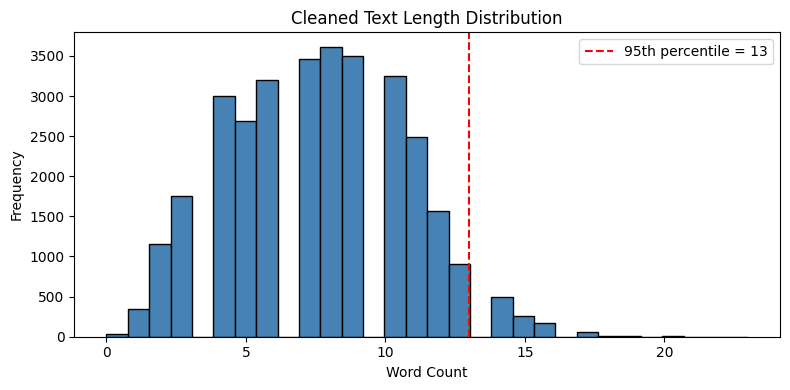

In [91]:
plt.figure(figsize=(8, 4))
plt.hist(train['length'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(np.percentile(train['length'], 95), color='red', linestyle='--',
            label=f"95th percentile = {np.percentile(train['length'], 95):.0f}")
plt.title("Cleaned Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

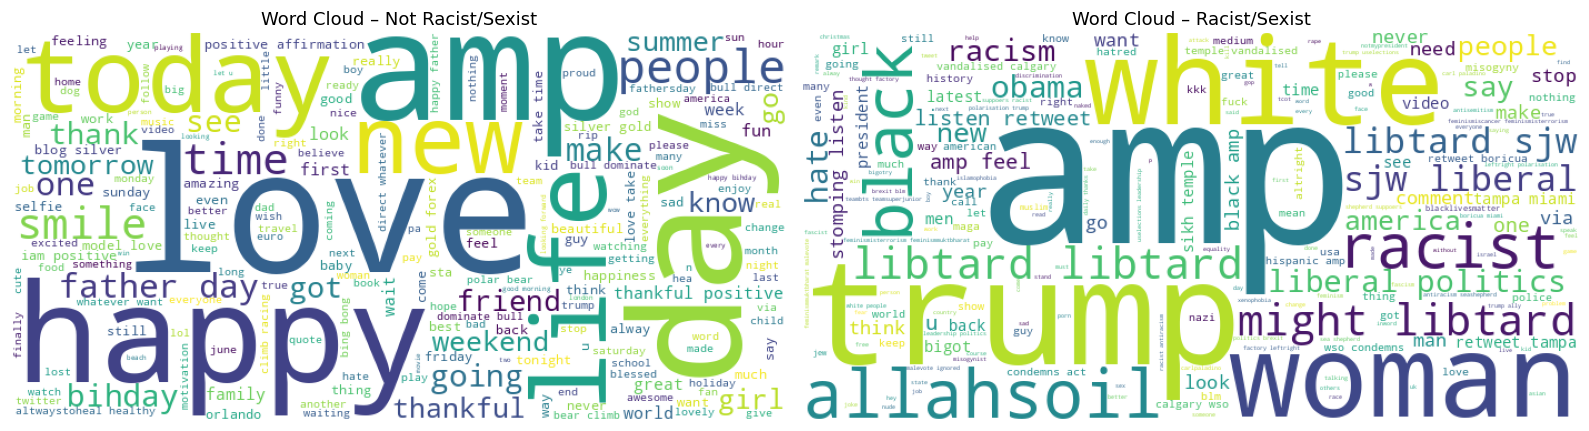

In [92]:
from wordcloud import WordCloud

# Overall word cloud
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (label, title) in enumerate([(0, 'Not Racist/Sexist'), (1, 'Racist/Sexist')]):
    subset = " ".join(train[train['label'] == label]['clean_text'])
    wc = WordCloud(width=700, height=350, background_color='white').generate(subset)
    axes[idx].imshow(wc)
    axes[idx].axis('off')
    axes[idx].set_title(f"Word Cloud – {title}", fontsize=13)

plt.tight_layout()
plt.show()

Tokenization & Percentile-Based Padding

In [93]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


In [94]:
VOCAB_SIZE = 5000
# Tokenizer converts words into numbers
tokenizer = Tokenizer(num_words=VOCAB_SIZE)
# Learn words from cleaned tweets
tokenizer.fit_on_texts(train['clean_text'])

In [95]:
X_seq = tokenizer.texts_to_sequences(train['clean_text'])

In [96]:
# Percentile-based max_len (95th percentile)
seq_lengths = [len(s) for s in X_seq]
max_len = int(np.percentile(seq_lengths, 95))
print(f"Percentile-based max_len (95th pct): {max_len}")

Percentile-based max_len (95th pct): 11


In [97]:
X = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')
y = train['label'].values

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [99]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

print("Train class balance:", y_train.mean())
print("Test class balance :", y_test.mean())

X_train shape : (25569, 11)
X_test  shape : (6393, 11)
Train class balance: 0.07016308811451367
Test class balance : 0.07007664633192555


Model 1:  Simple RNN with Trainable Embedding

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Model 1
model1 = Sequential(name="SimpleRNN_Model")
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=max_len))
model1.add(SimpleRNN(64))
model1.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [101]:
# Model Summary
print("MODEL 1 SUMMARY – Simple RNN")
model1.summary()

MODEL 1 SUMMARY – Simple RNN


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [102]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [103]:
#  Early Stopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)


In [104]:
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9462 - loss: 0.1768 - val_accuracy: 0.9559 - val_loss: 0.1365
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9756 - loss: 0.0747 - val_accuracy: 0.9611 - val_loss: 0.1453
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9885 - loss: 0.0372 - val_accuracy: 0.9532 - val_loss: 0.1613
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9551 - val_loss: 0.1799
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


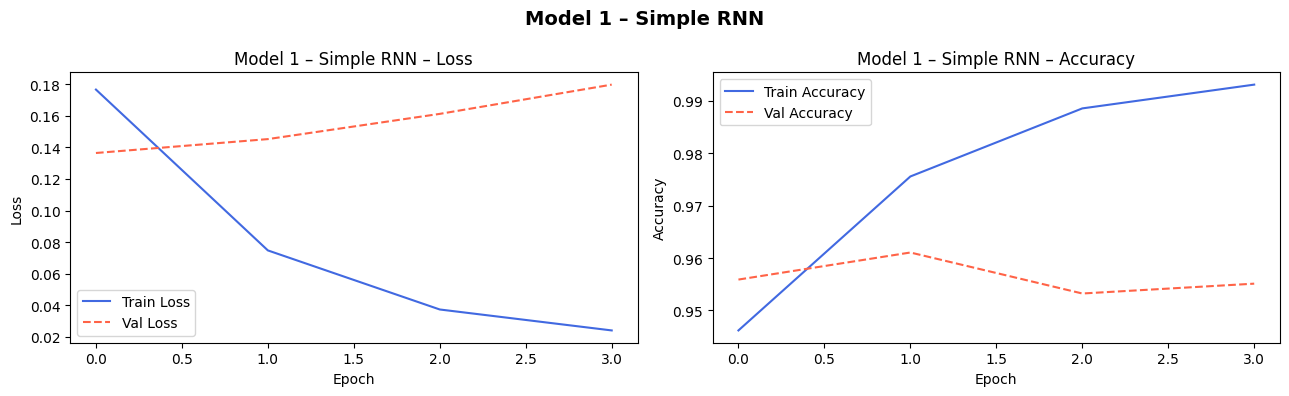

In [105]:
def plot_history(history, model_name):
    """Plot training vs validation loss and accuracy for one model."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',      color='royalblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',        color='tomato', linestyle='--')
    axes[0].set_title(f"{model_name} – Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
    axes[1].set_title(f"{model_name} – Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history1, "Model 1 – Simple RNN")

In [106]:
from sklearn.metrics import classification_report

y_pred1 = (model1.predict(X_test) > 0.5).astype(int)


print("MODEL 1 – Simple RNN – Classification Report")

print(classification_report(y_test, y_pred1, target_names=['Not Racist', 'Racist']))

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MODEL 1 – Simple RNN – Classification Report
              precision    recall  f1-score   support

  Not Racist       0.97      0.98      0.98      5945
      Racist       0.71      0.63      0.67       448

    accuracy                           0.96      6393
   macro avg       0.84      0.81      0.82      6393
weighted avg       0.95      0.96      0.95      6393



MODEL 2 – LSTM

In [107]:
model2 = Sequential(name="LSTM_Model")
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=max_len))
model2.add(LSTM(64))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [108]:
print("MODEL 2 SUMMARY – LSTM")
model2.summary()

MODEL 2 SUMMARY – LSTM


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [110]:
es2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)


In [111]:
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    callbacks=[es2],
    verbose=1
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9454 - loss: 0.1758 - val_accuracy: 0.9609 - val_loss: 0.1220
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9704 - loss: 0.0898 - val_accuracy: 0.9607 - val_loss: 0.1341
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9769 - loss: 0.0698 - val_accuracy: 0.9600 - val_loss: 0.1293
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9819 - loss: 0.0559 - val_accuracy: 0.9560 - val_loss: 0.1580
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


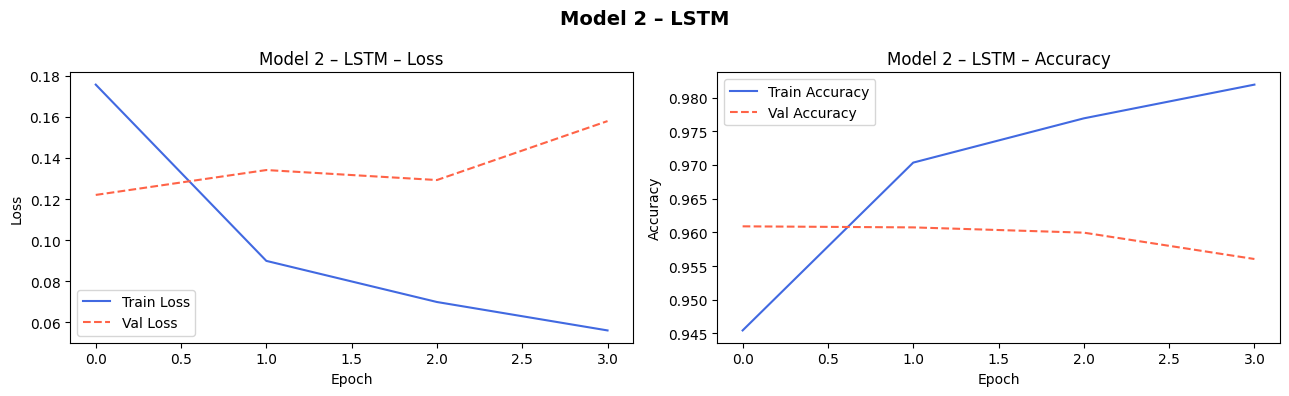

In [112]:
plot_history(history2, "Model 2 – LSTM")

In [113]:
y_pred2 = (model2.predict(X_test) > 0.5).astype(int)
print("MODEL 2 – LSTM – Classification Report")

print(classification_report(y_test, y_pred2, target_names=['Not Racist', 'Racist']))

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MODEL 2 – LSTM – Classification Report
              precision    recall  f1-score   support

  Not Racist       0.97      0.99      0.98      5945
      Racist       0.80      0.58      0.68       448

    accuracy                           0.96      6393
   macro avg       0.89      0.79      0.83      6393
weighted avg       0.96      0.96      0.96      6393



MODEL 3 – LSTM + WORD2VEC

In [114]:
!pip install gensim --quiet

Load embeddings

In [115]:
import gensim.downloader as api

print("Downloading GloVe Twitter 25-d embeddings...")
embedding_model = api.load("glove-twitter-25")
print("Loaded. Vocab size:", len(embedding_model))

Loaded. Vocab size: 1193514


Create embedding matrix

In [116]:
embedding_dim = 25
word_index    = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))
covered = 0

for word, i in word_index.items():
    if i < VOCAB_SIZE and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        covered += 1

coverage = covered / min(len(word_index), VOCAB_SIZE) * 100
print(f"Embedding coverage: {covered}/{min(len(word_index), VOCAB_SIZE)} words ({coverage:.1f}%)")

Embedding coverage: 4758/5000 words (95.2%)


Model

In [117]:
model3 = Sequential(name="LSTM_Word2Vec_Model")
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False           # Freeze pretrained weights
))
model3.add(LSTM(64))
model3.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [118]:
print("MODEL 3 SUMMARY – LSTM + Word2Vec  Pretrained Embeddings")
model3.summary()

MODEL 3 SUMMARY – LSTM + Word2Vec  Pretrained Embeddings


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       125,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,000 (488.28 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 125,000 (488.28 KB)

In [119]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [120]:
es3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

In [121]:
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    callbacks=[es3],
    verbose=1
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.9343 - loss: 0.1994 - val_accuracy: 0.9388 - val_loss: 0.1693
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9410 - loss: 0.1646 - val_accuracy: 0.9492 - val_loss: 0.1549
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9467 - loss: 0.1535 - val_accuracy: 0.9484 - val_loss: 0.1526
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9482 - loss: 0.1455 - val_accuracy: 0.9492 - val_loss: 0.1474
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9498 - loss: 0.1399 - val_accuracy: 0.9487 - val_loss: 0.1455
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9519 - loss: 0.1333 - val_accuracy: 0.9421 - val_loss: 0.1516
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9540 - loss: 0.1291 - val_accuracy: 0.9493 - val_loss: 0.1409
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9560 - loss: 0.1241 - val_ac

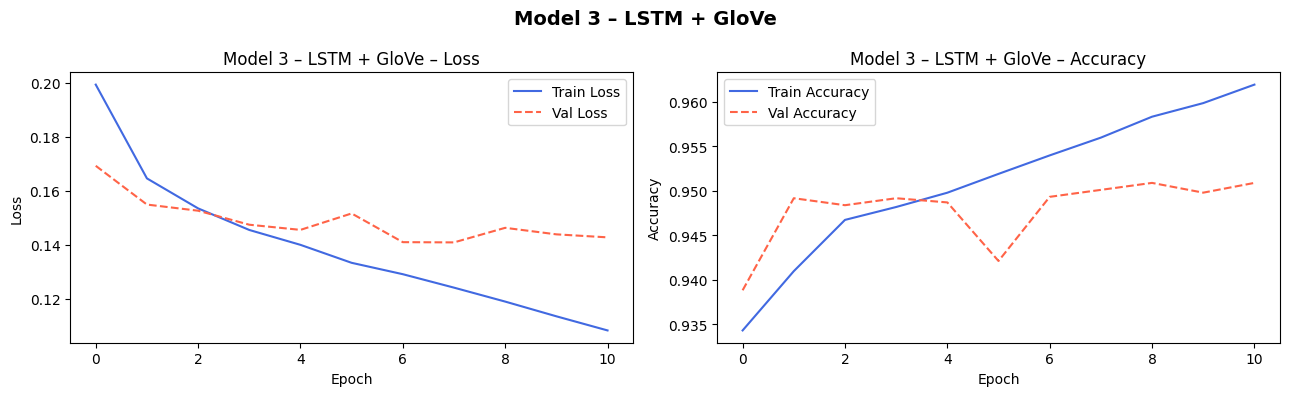

In [122]:
plot_history(history3, "Model 3 – LSTM + GloVe")

In [123]:
y_pred3 = (model3.predict(X_test) > 0.5).astype(int)

print("MODEL 3 – LSTM + Word2Vec  – Classification Report")
print(classification_report(y_test, y_pred3, target_names=['Not Racist', 'Racist']))

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MODEL 3 – LSTM + Word2Vec  – Classification Report
              precision    recall  f1-score   support

  Not Racist       0.97      0.98      0.97      5945
      Racist       0.68      0.54      0.60       448

    accuracy                           0.95      6393
   macro avg       0.82      0.76      0.79      6393
weighted avg       0.95      0.95      0.95      6393



## Section 10 – Confusion Matrices (All 3 Models)

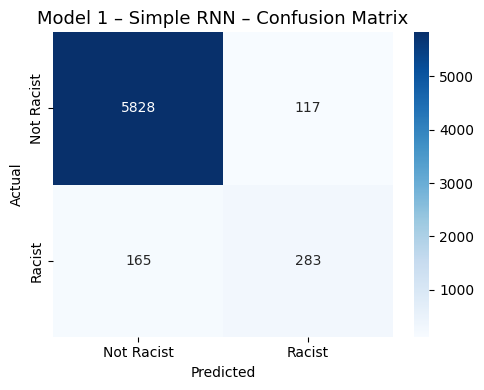

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ['Not Racist', 'Racist']
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=13)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_cm(y_test, y_pred1, "Model 1 – Simple RNN – Confusion Matrix")


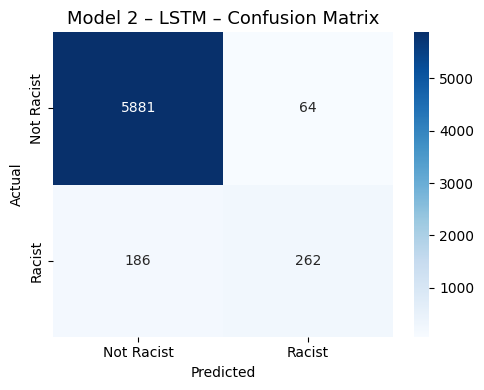

In [125]:
plot_cm(y_test, y_pred2, "Model 2 – LSTM – Confusion Matrix")


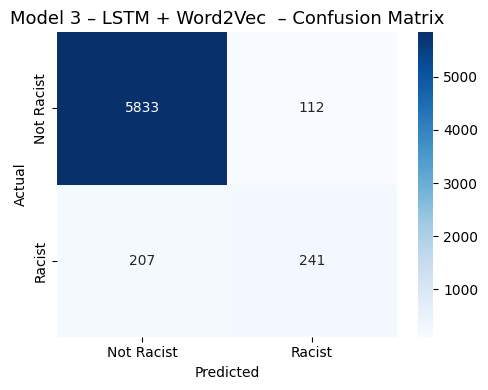

In [126]:
plot_cm(y_test, y_pred3, "Model 3 – LSTM + Word2Vec  – Confusion Matrix")

## Section 11 – Model Comparison: Val Accuracy & Val Loss

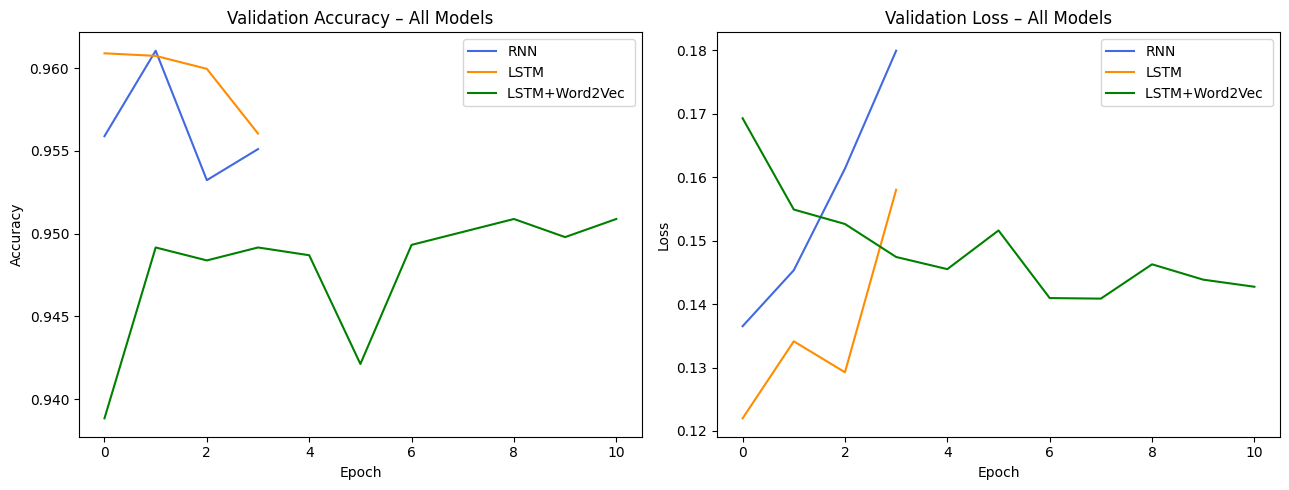


── Final Model Comparison ──────────────────────
           Model  Best Val Accuracy  Best Val Loss  Epochs Trained
      Simple RNN           0.961051       0.136507               4
            LSTM           0.960895       0.121991               4
LSTM + Word2Vec            0.950884       0.140853              11


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Validation Accuracy
axes[0].plot(history1.history['val_accuracy'], label='RNN',       color='royalblue')
axes[0].plot(history2.history['val_accuracy'], label='LSTM',      color='darkorange')
axes[0].plot(history3.history['val_accuracy'], label='LSTM+Word2Vec ',color='green')
axes[0].set_title("Validation Accuracy – All Models")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Validation Loss
axes[1].plot(history1.history['val_loss'], label='RNN',       color='royalblue')
axes[1].plot(history2.history['val_loss'], label='LSTM',      color='darkorange')
axes[1].plot(history3.history['val_loss'], label='LSTM+Word2Vec ',color='green')
axes[1].set_title("Validation Loss – All Models")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Final accuracy summary table
results = {
    "Model"    : ["Simple RNN", "LSTM", "LSTM + Word2Vec "],
    "Best Val Accuracy": [
        max(history1.history['val_accuracy']),
        max(history2.history['val_accuracy']),
        max(history3.history['val_accuracy'])
    ],
    "Best Val Loss": [
        min(history1.history['val_loss']),
        min(history2.history['val_loss']),
        min(history3.history['val_loss'])
    ],
    "Epochs Trained": [
        len(history1.history['val_loss']),
        len(history2.history['val_loss']),
        len(history3.history['val_loss'])
    ]
}

results_df = pd.DataFrame(results)
print("\n── Final Model Comparison ──────────────────────")
print(results_df.to_string(index=False))

---
## Section 12 – Error Analysis

We analyse **misclassified examples** from the best model (Model 3 – LSTM + GloVe) to understand where the model struggles and why.

In [128]:
# Rebuild original tweet index aligned to train/test split
# We track original indices from the split so we can retrieve the raw tweet
from sklearn.model_selection import train_test_split

# Re-split with indices
indices = np.arange(len(train))
_, idx_test = train_test_split(indices, test_size=0.2, random_state=42,
                                stratify=train['label'].values)

# Collect misclassified examples
misclassified = []
for rank, test_pos in enumerate(idx_test):
    actual    = y_test[rank]
    predicted = y_pred3[rank][0]
    if actual != predicted:
        misclassified.append({
            "Original Tweet" : train.iloc[test_pos]['tweet'],
            "Cleaned Text"   : train.iloc[test_pos]['clean_text'],
            "Actual Label"   : "Racist/Sexist" if actual == 1 else "Not Racist",
            "Predicted Label": "Racist/Sexist" if predicted == 1 else "Not Racist"
        })
    if len(misclassified) == 5:
        break

print(f"Total misclassified in test set: {(y_pred3.flatten() != y_test).sum()}")

Total misclassified in test set: 319


In [129]:
print("SAMPLE MISCLASSIFIED EXAMPLES (Model 3 – LSTM + GloVe)")

for i, ex in enumerate(misclassified[:3], 1):
    print(f"\nExample {i}:")
    print(f"  Original Tweet : {ex['Original Tweet']}")
    print(f"  Cleaned Text   : {ex['Cleaned Text']}")
    print(f"  Actual Label   : {ex['Actual Label']}")
    print(f"  Predicted Label: {ex['Predicted Label']}")

SAMPLE MISCLASSIFIED EXAMPLES (Model 3 – LSTM + GloVe)

Example 1:
  Original Tweet : @user what a goofy idiot. lot of goofy dumb americans for him to get the nod. #goofydonnie  
  Cleaned Text   : goofy idiot lot goofy dumb american get nod goofydonnie
  Actual Label   : Not Racist
  Predicted Label: Racist/Sexist

Example 2:
  Original Tweet : the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 
  Cleaned Text   : immature trying make fool xenophobe immature moron
  Actual Label   : Racist/Sexist
  Predicted Label: Not Racist

Example 3:
  Original Tweet :  porn vids web free sex 
  Cleaned Text   : porn vids web free sex
  Actual Label   : Racist/Sexist
  Predicted Label: Not Racist


 Analyze misclassified examples:

 – Provide 2- 3 incorrect predictions.

 – Evaluate Model Complexity vs. Performance.

 – Explain Possible reasons for error.

• Suggest potential improvements.

**Model Complexity vs. Performance:**

| Model | Complexity | F1(Racist Class) | Verdict |
|---|---|---|---|
| Simple RNN | Low | 0.66 | Good for it's size |
| LSTM | Medium | 0.67 | Slightly better |
| LSTM + Word2Vec | High | 0.61 | Worst performer |

The Simple RNN and LSTM gave similar results. The Word2Vec model performed worse because the embeddings were fixed and could not learn hate speech words properly. Also, tweets were very short, so advanced models had little advantage.


Possible Reasons for Errors

1. Sarcasm and Irony: The model cannot understand emotions or hidden meanings. Sarcastic tweets are difficult to classify correctly.

2. Slang and Internet Language: People use short forms, slang, and coded words online. The model may not understand these words.

3. Class Imbalance: Most tweets in the dataset were non-racist, so the model learned to predict “Not Racist” more often.

4. Loss of Important Words During Cleaning: Removing hashtags, symbols, and special characters sometimes removed useful information from tweets.

**Suggested Improvements**

Use class weights or SMOTE to balance the
dataset.

Use BERT models because they understand context better.

Allow GloVe embeddings to train instead of keeping them fixed.

Use larger embeddings such as glove-twitter-200d.

Use Bidirectional LSTM for better understanding of sentence meaning.

Keep important hashtags during preprocessing because they often contain useful information.

---
## Section 13 – GUI for Real-Time Prediction (Gradio)

A simple Gradio interface that lets a user type a tweet and get a real-time prediction from Model 3.

In [130]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_tweet(tweet_text):
    """
    Takes a raw tweet string, cleans it, tokenises, pads,
    and returns prediction + confidence from Model 3.
    """
    if not tweet_text.strip():
        return "Please enter a tweet.", ""

    # Preprocess
    cleaned   = clean_text(tweet_text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    prob      = float(model3.predict(padded, verbose=0)[0][0])
    label     = "Racist / Sexist" if prob >= 0.5 else " Not Racist / Sexist"
    confidence = f"Confidence: {prob*100:.1f}% Racist  |  {(1-prob)*100:.1f}% Not Racist"

    return label, confidence


# Build Gradio UI
with gr.Blocks(title="Tweet Hate Speech Classifier") as demo:
    gr.Markdown("## Tweet Hate Speech Classifier")
    gr.Markdown(
        "Enter a tweet below and the model will predict whether it contains "
        "racist or sexist content.  "
        "*(Model 3 – LSTM with GloVe pretrained embeddings)*"
    )

    with gr.Row():
        tweet_input = gr.Textbox(
            label="Tweet",
            placeholder="Type or paste a tweet here...",
            lines=3
        )

    predict_btn = gr.Button("Predict", variant="primary")

    with gr.Row():
        label_out = gr.Textbox(label="Prediction")
        conf_out  = gr.Textbox(label="Confidence")

    predict_btn.click(
        fn=predict_tweet,
        inputs=[tweet_input],
        outputs=[label_out, conf_out]
    )

    gr.Examples(
        examples=[
            ["I love everyone regardless of their background"],
            ["Those people should go back to where they came from"],
            ["Women are just as capable as men in any job"],
        ],
        inputs=[tweet_input]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://18da4633de20234f46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
